# Planning Observations for Transits and Eclipses

This tutorial shows how to plan time-series observations of transiting exoplanets and eclipsing binaries. The workflow is designed for REU students who will mostly observe from the ETAMU observatory, but the same tools also work for SARA sites such as CTIO, KPNO, and Roque de los Muchachos.

The basic idea is simple:

1. Search for observable events over the next 1--2 weeks.
2. Select 1--2 targets for a specific night.
3. Make a detailed nightly plan with an airmass diagram, event window, twilight times, and sky field.
4. Check the Moon and weather.
5. Keep an observation log that records what was planned, what actually happened, and where the data went.

```{admonition} What you should already know
:class: tip

Before using this tutorial, review the companion material on [celestial sphere and sky coordinates](https://saturnaxis.github.io/exoplanet-binary/Tutorials/celestial-sphere.html#). You should be comfortable with right ascension, declination, altitude, azimuth, meridian transit, and why targets are best observed when they are high in the sky.
```

```{admonition} Main planning rule
:class: warning

Always record the time system. Observing schedules are usually written in UTC, while observers naturally think in local civil dates. A target observed on the local night of July 10 may have a mid-eclipse time on July 11 in UTC.
```

## 1. The two-stage observing workflow

Observation planning has two different jobs.

- The first job is **event discovery**: find all transits or eclipses that occur during a future date range and are observable from one or more sites.

- The second job is **nightly planning**: once you know the target and date, make a detailed plan for that specific night. 

| Stage | Main question | Main tool | Output |
|---|---|---|---|
| 1--2 week search | What events are observable soon? | weekly event-search notebook | CSV table of candidate events |
| Nightly plan | What should we observe tonight and when? | nightly planning notebook | Airmass plot, finder chart, observing blocks |
| Weather check | Is it worth opening? | Clear Sky Chart, local weather, observer judgment | Go / no-go / backup decision |
| Observation log | What actually happened? | Markdown log | Reproducible record for reduction |

## 2. Required Python packages

Run this at the beginning of a fresh Colab or Jupyter session.

> !pip install astroplan astroquery ipyaladin


Then import the standard planning packages.



In [1]:
import io
import warnings
from datetime import date, datetime, timedelta

import astropy.units as u
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pytz
from astropy.coordinates import EarthLocation, SkyCoord, get_sun
from astropy.table import Table, Column, unique, vstack
from astropy.time import Time
from astroplan import EclipsingSystem, FixedTarget, Observer
from astroplan.plots import plot_airmass
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from astroquery.vizier import Vizier
from IPython.display import display

warnings.filterwarnings("ignore")

- `astroplan` is the key planning package. It handles observers, targets, twilight times, airmass plots, and periodic events such as transits and eclipses. `astropy` handles coordinates, times, and site locations. 

- `astroquery` downloads catalog information. 

- `ipyaladin` is optional but very useful for inspecting the sky field around a target.

## 3. Define the observing sites

The students will usually plan for ETAMU first. The other sites are included so that the same functions can be used for SARA runs.



In [2]:
SITE_INFO = {
    "ETAMU": {"lon": -95.923078, "lat": 33.183389, "height_m": 158, "timezone": "US/Central"},
    "KPNO": {"lon": -111.5983, "lat": 31.9582, "height_m": 2090, "timezone": "US/Arizona"},
    "CTIO": {"lon": -70.8062, "lat": -30.1690, "height_m": 2215, "timezone": "America/Santiago"},
    "Roque de los Muchachos": {"lon": -17.8917, "lat": 28.7561, "height_m": 2396, "timezone": "Atlantic/Canary"},
}

SITE_ORDER = ["ETAMU", "Roque de los Muchachos", "KPNO", "CTIO"]

def make_observer(site_name):
    """Return an astroplan Observer and timezone string for a named site."""
    info = SITE_INFO[site_name]
    location = EarthLocation.from_geodetic(lon=info["lon"]*u.deg, lat=info["lat"]*u.deg, height=info["height_m"]*u.m)
    observer = Observer(location=location, name=site_name, timezone=info["timezone"])
    return observer, info["timezone"]


```{admonition} Why define the sites manually?
:class: tip

`Observer.at_site()` is convenient, but local site lists can change between computers and package versions. Defining the sites manually makes student notebooks more reproducible. It also lets us attach the correct local time zone to each site.
```

## 4. Search for observable events over 1--2 weeks

The weekly search should answer this question:

> Which primary or secondary eclipses occur soon, are high enough in the sky, happen during darkness, and have reasonable magnitudes?

For REU observing, do not start by building a semester-long schedule. Start with the next 7--14 local nights. A short window is easier to verify against the weather, the Moon, student availability, and telescope constraints.

### 4.1 Choose the date range and selection limits



In [3]:
START_DATE = date(2026, 6, 8)  # YYYY, MM, DD
END_DATE = date(2026, 6, 15)
SITES_TO_CHECK = ["ETAMU"] #add "KPNO", "CTIO", "Roque de los Muchachos" as needed
UTC_HOUR_START = 2
UTC_HOUR_END = 10
MAG_MIN = 10
MAG_MAX = 15
MIN_ALTITUDE_DEG = 30
MAX_MORPHOLOGY = 0.3


Use a short date range when students are planning actual observations. Increase the range only when building a campaign schedule.

### 4.2 Download candidate systems

The example campaign notebook merges three useful sources:

- TESS eclipsing binaries from VizieR catalog `J/ApJS/258/16`.
- Kepler eclipsing binaries from VizieR catalog `J/AJ/151/68`.
- Known transiting hot Jupiters from the NASA Exoplanet Archive.

The TESS and Kepler catalogs store epoch values differently, so the code later converts each catalog into a common Julian Date system before computing eclipse times.



In [4]:
def get_all_potential_targets(start_date, end_date, mag_min=10, mag_max=15, max_morphology=0.3):
    """Download a merged table of TESS EBs, Kepler EBs, and hot Jupiters near the seasonally useful RA range."""
    midpoint_date = start_date + (end_date - start_date) / 2
    sun_ra_deg = get_sun(Time(midpoint_date.isoformat())).ra.deg
    optimal_ra_deg = (sun_ra_deg + 180) % 360
    ra_window_deg = 180
    ra_min = (optimal_ra_deg - ra_window_deg/2) % 360
    ra_max = (optimal_ra_deg + ra_window_deg/2) % 360
    ra_query = f">={ra_min}|<={ra_max}" if ra_max < ra_min else f">={ra_min}&<={ra_max}"
    print(f"Searching near seasonally useful RA. Optimal RA ≈ {optimal_ra_deg:.1f} deg; query range {ra_min:.1f}--{ra_max:.1f} deg.")

    Vizier.ROW_LIMIT = -1
    tess_result = Vizier.query_constraints(catalog="J/ApJS/258/16", Morph=f"<={max_morphology}", Tmag=f">={mag_min} & <={mag_max}", RAJ2000=ra_query)
    if tess_result:
        tess_table = tess_result[0]
        tess_table.rename_column("TIC", "ID")
        tess_table["ID"] = tess_table["ID"].astype(str)
        tess_table["Catalog"] = "TESS"
        tess_table["Tmag"].name = "Mag"
        tess_table.keep_columns(["ID", "RAJ2000", "DEJ2000", "Mag", "Catalog", "Per", "BJD0"])
    else:
        tess_table = Table(names=["ID", "RAJ2000", "DEJ2000", "Mag", "Catalog", "Per", "BJD0"])

    kepler_result = Vizier.query_constraints(catalog="J/AJ/151/68", Kpmag=f">={mag_min} & <={mag_max}")
    if kepler_result:
        kepler_table = kepler_result[0]
        if ra_max < ra_min:
            kepler_table = kepler_table[(kepler_table["_RA"] >= ra_min) | (kepler_table["_RA"] <= ra_max)]
        else:
            kepler_table = kepler_table[(kepler_table["_RA"] >= ra_min) & (kepler_table["_RA"] <= ra_max)]
        kepler_table.rename_columns(["KIC", "_RA", "_DE", "Kpmag"], ["ID", "RAJ2000", "DEJ2000", "Mag"])
        kepler_table["ID"] = kepler_table["ID"].astype(str)
        kepler_table["Catalog"] = "Kepler"
        kepler_table.keep_columns(["ID", "RAJ2000", "DEJ2000", "Mag", "Catalog", "Per", "BJD0"])
    else:
        kepler_table = Table(names=["ID", "RAJ2000", "DEJ2000", "Mag", "Catalog", "Per", "BJD0"])

    hj_ra_query = f"(ra > {ra_min} or ra < {ra_max})" if ra_max < ra_min else f"(ra > {ra_min} and ra < {ra_max})"
    hj_table = NasaExoplanetArchive.query_criteria(table="ps", select="pl_name, ra, dec, sy_vmag, pl_orbper, pl_tranmid, default_flag", where=f"sy_vmag <= {mag_max} AND pl_orbper < 10 AND pl_radj > 0.8 AND discoverymethod = 'Transit' AND {hj_ra_query}")
    hj_table.sort(["pl_name", "default_flag"], reverse=True)
    hj_table = unique(hj_table, keys="pl_name", keep="first")
    hj_table = hj_table[~np.isnan(hj_table["pl_tranmid"])]
    hj_table.rename_columns(["pl_name", "ra", "dec", "sy_vmag", "pl_orbper", "pl_tranmid"], ["ID", "RAJ2000", "DEJ2000", "Mag", "Per", "BJD0"])
    hj_table["Catalog"] = "HotJupiter"
    hj_table["ID"] = [name.replace(" ", "") for name in hj_table["ID"]]
    hj_table = Table([Column(data=hj_table[col].value, name=col, dtype=float) if col not in ["ID", "Catalog"] else Column(data=hj_table[col], name=col) for col in ["ID", "RAJ2000", "DEJ2000", "Mag", "Catalog", "Per", "BJD0"]])

    all_targets = vstack([tess_table, kepler_table, hj_table], metadata_conflicts="silent")
    print(f"Total candidate systems: {len(all_targets)}")
    return all_targets



### 4.3 Convert ephemerides and compute primary/secondary events

An ephemeris predicts when the eclipse or transit happens. The key pieces are:

- `BJD0`: a reference eclipse or transit time.
- `Per`: the orbital period.
- `Type`: primary or secondary event.

The campaign notebook uses `astroplan.EclipsingSystem` to compute upcoming primary and secondary events.



In [5]:
def catalog_epoch_to_jd(row):
    """Convert catalog-specific epoch conventions into Julian Date."""
    if row["Catalog"] == "TESS":
        return row["BJD0"] + 2457000
    if row["Catalog"] == "Kepler":
        return row["BJD0"] + 2400000
    if row["Catalog"] == "HotJupiter":
        return row["BJD0"]
    raise ValueError(f"Unknown catalog: {row['Catalog']}")

def catalog_name(row):
    """Return a clean display name."""
    if row["Catalog"] == "TESS":
        return f"TIC {row['ID']}"
    if row["Catalog"] == "Kepler":
        return f"KIC {row['ID']}"
    if row["Catalog"] == "HotJupiter":
        return f"HJ {row['ID']}"
    return str(row["ID"])

def pre_calculate_events_for_target(row, start_time, end_time):
    """Calculate all primary and secondary events for one target in a date range."""
    if not (np.isfinite(row["BJD0"]) and np.isfinite(row["Per"]) and row["Per"] > 0):
        return []
    bjd0 = catalog_epoch_to_jd(row)
    name = catalog_name(row)
    system = EclipsingSystem(primary_eclipse_time=Time(bjd0, format="jd"), orbital_period=row["Per"]*u.day, name=name)
    n_eclipses = int(((end_time - start_time).jd / row["Per"]) * 1.2) + 2
    events = []
    for event_type, event_times in [("Primary", system.next_primary_eclipse_time(start_time, n_eclipses=n_eclipses)), ("Secondary", system.next_secondary_eclipse_time(start_time, n_eclipses=n_eclipses))]:
        for event_time in event_times:
            if event_time > end_time:
                break
            events.append({"Name": name, "Catalog": row["Catalog"], "BJD0_JD": bjd0, "Eclipse_Time": event_time, "Type": event_type, "RAJ2000": row["RAJ2000"], "DEJ2000": row["DEJ2000"], "Mag": row["Mag"], "Period_days": row["Per"]})
    return events



### 4.4 Apply observing constraints

A target is not useful just because an eclipse occurs. It must be observable from the site at the right time. The minimum checks are:

- the target is above the altitude limit;
- the Sun is below the twilight limit;
- the event happens in a useful part of the night;
- the target is not too bright or too faint for the observing setup.



In [6]:
def local_civil_date(event_time, observer):
    """Return the local civil date for an event time and observer."""
    utc_dt = event_time.to_datetime(timezone=pytz.utc)
    local_dt = utc_dt.astimezone(pytz.timezone(str(observer.timezone)))
    return local_dt.date().isoformat()

def check_event_observability(event, observer, utc_hour_start=0, utc_hour_end=12, min_altitude_deg=30):
    """Return an output dictionary if the event is observable; otherwise return None."""
    event_time = event["Eclipse_Time"]
    utc_hour = event_time.to_datetime().hour + event_time.to_datetime().minute/60
    if not (utc_hour_start <= utc_hour <= utc_hour_end):
        return None
    coord = SkyCoord(ra=event["RAJ2000"]*u.deg, dec=event["DEJ2000"]*u.deg)
    altaz = observer.altaz(event_time, coord)
    sun_alt = observer.sun_altaz(event_time).alt.degree
    if altaz.alt.degree <= min_altitude_deg:
        return None
    if sun_alt >= -12:
        return None
    return {"Obs_Date_Local": local_civil_date(event_time, observer), "Observatory": observer.name, "Name": event["Name"], 
            "Catalog": event["Catalog"], "BJD0_JD": event["BJD0_JD"], "Eclipse_Time_UTC": event_time.iso, "Type": event["Type"], 
            "Altitude_deg": round(altaz.alt.degree, 1), "Period_days": event["Period_days"], 
            "RAJ2000": event["RAJ2000"], "DEJ2000": event["DEJ2000"], "Mag": round(event["Mag"], 2) if np.isfinite(event["Mag"]) else np.nan}

### 4.5 Build and save the 1--2 week event table

```{admonition} Build time
:class: note

The initial search may turn up a few thousand events or systems.  If this is the case, then building the table can take several (${\sim}10$) minutes.  Take this an opportunity to get a cup of coffee :coffee: or tea :tea:!
```

In [13]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import os

def chunk_list(items, chunk_size):
    """Split a list into chunks."""
    for i in range(0, len(items), chunk_size):
        yield items[i:i + chunk_size]

def check_event_chunk(site_name, events_chunk, utc_hour_start, utc_hour_end, min_altitude_deg):
    """Check observability for a chunk of events at one site."""
    observer, timezone_str = make_observer(site_name)
    observable_events = []
    for event in events_chunk:
        result = check_event_observability(event, observer, utc_hour_start=utc_hour_start, utc_hour_end=utc_hour_end, min_altitude_deg=min_altitude_deg)
        if result is not None:
            observable_events.append(result)
    return observable_events

def build_observable_event_table_parallel(start_date, end_date, sites_to_check, max_workers=None, chunk_size=100):
    """Build a table of observable primary and secondary events over a date range using parallel workers."""
    if max_workers is None:
        max_workers = min(8, os.cpu_count() or 1)

    targets = list(get_all_potential_targets(start_date, end_date, mag_min=MAG_MIN, mag_max=MAG_MAX, max_morphology=MAX_MORPHOLOGY))
    start_time = Time(start_date.isoformat())
    end_time = Time((end_date + timedelta(days=1)).isoformat())

    all_events = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(pre_calculate_events_for_target, row, start_time, end_time) for row in targets]
        for future in as_completed(futures):
            all_events.extend(future.result())

    observable_events = []
    tasks = []
    for site_name in sites_to_check:
        for events_chunk in chunk_list(all_events, chunk_size):
            tasks.append((site_name, events_chunk))

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(check_event_chunk, site_name, events_chunk, UTC_HOUR_START, UTC_HOUR_END, MIN_ALTITUDE_DEG) for site_name, events_chunk in tasks]
        for future in as_completed(futures):
            observable_events.extend(future.result())

    table = Table(rows=observable_events)
    if len(table) > 0:
        table.sort(["Obs_Date_Local", "Observatory", "Eclipse_Time_UTC"])

    return table

master_table = build_observable_event_table_parallel(START_DATE, END_DATE, SITES_TO_CHECK, max_workers=8, chunk_size=100)
master_table.write("observable_events_next_two_weeks.csv", format="csv", overwrite=True)
master_table[["Obs_Date_Local", "Observatory", "Name", "Type", "Eclipse_Time_UTC", "Altitude_deg", "Mag", "Period_days"]][:10].pprint_all()

Searching near seasonally useful RA. Optimal RA ≈ 258.8 deg; query range 168.8--348.8 deg.
Total candidate systems: 2526
Obs_Date_Local Observatory     Name        Type       Eclipse_Time_UTC    Altitude_deg  Mag  Period_days
-------------- ----------- ------------ --------- ----------------------- ------------ ----- -----------
    2026-06-07       ETAMU HJ Qatar-10b   Primary 2026-06-08 02:43:12.058         33.3 12.87    1.645321
    2026-06-07       ETAMU KIC 10447902   Primary 2026-06-08 02:54:36.335         32.5 14.92   0.3374641
    2026-06-07       ETAMU KIC 10255110 Secondary 2026-06-08 02:57:35.844         31.6 13.49   0.3367025
    2026-06-07       ETAMU KIC 12350008   Primary 2026-06-08 03:00:47.423         30.2  14.6   0.1845296
    2026-06-07       ETAMU HJ KELT-23Ab Secondary 2026-06-08 03:03:08.482         53.5 10.31    2.255251
    2026-06-07       ETAMU KIC 09004380   Primary 2026-06-08 03:09:26.160         31.8 14.24   0.2503325
    2026-06-07       ETAMU KIC 10389809


```{admonition} Student checkpoint
:class: tip

Before selecting targets, confirm that the table is sorted by local observing date, not only by UTC date. Then check whether the same target has both a primary and secondary event in the planning window. Paired primary+secondary coverage is often more valuable than isolated events.
```

## 5. Select targets for a night

For each local night, choose 1--2 targets. In most cases, use this priority order:

1. Targets needed for a larger campaign, such as a paired primary/secondary eclipse.
2. TESS eclipsing binaries with good altitude and useful brightness.
3. Targets that stay above the altitude limit for the full observing block.
4. Targets with clean fields and comparison stars.
5. Backup targets in case the primary target is blocked by clouds, trees, Moon proximity, or technical issues.

A simple selection score is useful but should not replace judgment. For example:



In [22]:
def add_simple_merit_score(table):
    """Add a simple score that rewards high altitude and brighter targets within the useful magnitude range."""
    table = table.copy()
    table["Merit_Score"] = table["Altitude_deg"] + (15 - table["Mag"])
    table.sort(["Obs_Date_Local", "Observatory", "Merit_Score"])
    table.reverse()
    return table

ranked_table = add_simple_merit_score(master_table)
ranked_table[["Obs_Date_Local", "Observatory", "Name", "Type", "Altitude_deg", "Mag", "Merit_Score"]][:20]

Obs_Date_Local,Observatory,Name,Type,Altitude_deg,Mag,Merit_Score
str10,str5,str16,str9,float64,float64,float64
2026-06-15,ETAMU,KIC 01161345,Secondary,85.3,11.63,88.67
2026-06-15,ETAMU,KIC 03443519,Secondary,84.0,11.48,87.52
2026-06-15,ETAMU,KIC 02556127,Secondary,85.3,12.9,87.39999999999999
2026-06-15,ETAMU,HJ HAT-P-2b,Secondary,80.6,8.72,86.88
2026-06-15,ETAMU,KIC 02309587,Primary,85.3,13.93,86.37
2026-06-15,ETAMU,KIC 04074532,Primary,83.8,13.27,85.53
2026-06-15,ETAMU,KIC 03956545,Primary,84.0,13.99,85.01
2026-06-15,ETAMU,KIC 03954798,Primary,83.6,13.61,84.99
2026-06-15,ETAMU,KIC 02447893,Primary,84.4,14.49,84.91000000000001



```{warning}
A merit score is only a first pass. Do not select a target without checking the full airmass curve, Moon, field quality, and weather.
```

## 6. Make a detailed nightly plan

Once targets are chosen, switch from the event-search table to the nightly planning notebook. This is where the nightly planning notebook is most useful.

A good nightly plan should include:

- site, local date, and time zone;
- sunset, sunrise, nautical twilight, and astronomical twilight;
- airmass/altitude curve for each target;
- a visible mark for the mid-eclipse or mid-transit time;
- a shaded observing block around the event;
- a finder chart or sky field;
- primary and backup target choices;
- exposure strategy and filter choice;
- weather and Moon notes.

### 6.1 Helper functions for local and UTC time



In [ ]:
def time_from_local_evening(obs_day, timezone_str, local_hour=20):
    """Return an astropy Time corresponding to local_hour on the local civil observing date."""
    local_tz = pytz.timezone(timezone_str)
    local_dt = datetime.strptime(f"{obs_day} {local_hour:02d}:00:00", "%Y-%m-%d %H:%M:%S")
    utc_dt = local_tz.localize(local_dt).astimezone(pytz.utc)
    return Time(utc_dt)

def print_utc_and_local(label, time_obj, timezone_str):
    """Print one event time in both UTC and local time."""
    local_tz = pytz.timezone(timezone_str)
    utc_dt = time_obj.to_datetime(timezone=pytz.utc)
    local_dt = utc_dt.astimezone(local_tz)
    print(f"{label:<32} {utc_dt.strftime('%Y-%m-%d %H:%M UTC'):>24}   {local_dt.strftime('%Y-%m-%d %I:%M %p'):>24}")

def add_localtime_top_axis(ax, timezone_str):
    """Add a top x-axis with local time labels to a Matplotlib date plot whose bottom axis is UTC."""
    top_ax = ax.twiny()
    top_ax.set_xlim(ax.get_xlim())
    ticklocs = ax.get_xticks()
    local_tz = pytz.timezone(timezone_str)
    local_labels = [mdates.num2date(loc).replace(tzinfo=pytz.utc).astimezone(local_tz).strftime("%H:%M") for loc in ticklocs]
    top_ax.set_xticks(ticklocs)
    top_ax.set_xticklabels(local_labels, rotation=-15)
    top_ax.set_xlabel(f"Local Time ({timezone_str})")
    return top_ax


### 6.2 Plot one target for one night

This function looks up the target coordinates and event time from the event table. It then makes the airmass plot and marks the event window.



In [23]:
def get_event_row(event_table, obs_day, site_name, target_name):
    """Return the first matching event row for one target on one local observing date."""
    matches = event_table[(event_table["Obs_Date_Local"] == obs_day) & (event_table["Observatory"] == site_name) & (event_table["Name"] == target_name)]
    if len(matches) == 0:
        raise ValueError(f"No event found for {target_name} on {obs_day} at {site_name}.")
    return matches[0]

def plot_night_target_plan(event_table, obs_day, site_name, target_name, event_duration_hr=3, max_airmass=2.5):
    """Make an airmass plot for a selected event and mark the eclipse/transit window."""
    observer, timezone_str = make_observer(site_name)
    row = get_event_row(event_table, obs_day, site_name, target_name)
    now = time_from_local_evening(obs_day, timezone_str, local_hour=20)
    sunset = observer.sun_set_time(now, which="nearest")
    sunrise = observer.sun_rise_time(now, which="next")
    evening_nautical = observer.twilight_evening_nautical(now, which="nearest")
    evening_astronomical = observer.twilight_evening_astronomical(now, which="nearest")
    morning_astronomical = observer.twilight_morning_astronomical(now, which="next")
    morning_nautical = observer.twilight_morning_nautical(now, which="next")

    print(f"Observatory: {site_name}")
    print(f"Target: {target_name}")
    print(f"Event type: {row['Type']}")
    print(f"Magnitude: {row['Mag']}")
    print(f"{'Event':<32} {'UTC':>24}   {'Local Time':>24}")
    print("-"*86)
    for label, time_obj in [("Sunset", sunset), ("End nautical twilight", evening_nautical), ("End astronomical twilight", evening_astronomical), ("Start astronomical twilight", morning_astronomical), ("Start nautical twilight", morning_nautical), ("Sunrise", sunrise)]:
        print_utc_and_local(label, time_obj, timezone_str)

    coord = SkyCoord(ra=row["RAJ2000"]*u.deg, dec=row["DEJ2000"]*u.deg, frame="icrs")
    target = FixedTarget(coord=coord, name=target_name)
    event_mid = Time(row["Eclipse_Time_UTC"])
    time_range = sunset + np.linspace(-1, (sunrise - sunset).to_value(u.hour) + 1, 200)*u.hour

    fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
    plot_airmass(target, observer, time_range, ax=ax, max_airmass=max_airmass, brightness_shading=True, altitude_yaxis=True)
    ax.axvline(evening_nautical.to_datetime(), linestyle="--", label="Nautical twilight")
    ax.axvline(evening_astronomical.to_datetime(), linestyle=":", label="Astronomical twilight")
    ax.axvline(morning_astronomical.to_datetime(), linestyle=":")
    ax.axvline(morning_nautical.to_datetime(), linestyle="--")
    ax.axvline(event_mid.to_datetime(), linestyle="-", linewidth=2, label=f"{row['Type']} mid-event")
    ax.axvspan((event_mid - (event_duration_hr/2)*u.hour).to_datetime(), (event_mid + (event_duration_hr/2)*u.hour).to_datetime(), alpha=0.2,color='red', label=f"{event_duration_hr:.1f} hr event window")
    ax.set_title(f"{target_name} from {site_name} on local night {obs_day}")
    ax.set_xlabel("UTC Time")
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", rotation=-15)
    ax.legend(loc="best")
    add_localtime_top_axis(ax, timezone_str)
    fig.tight_layout()
    return fig, ax


Example use:



Observatory: ETAMU
Target: KIC 10447902
Event type: Primary
Magnitude: 14.92
Event                                                 UTC                 Local Time
--------------------------------------------------------------------------------------
Sunset                               2026-06-08 01:26 UTC        2026-06-07 08:26 PM
End nautical twilight                2026-06-08 02:34 UTC        2026-06-07 09:34 PM
End astronomical twilight            2026-06-08 03:12 UTC        2026-06-07 10:12 PM
Start astronomical twilight          2026-06-08 09:32 UTC        2026-06-08 04:32 AM
Start nautical twilight              2026-06-08 10:10 UTC        2026-06-08 05:10 AM
Sunrise                              2026-06-08 11:18 UTC        2026-06-08 06:18 AM


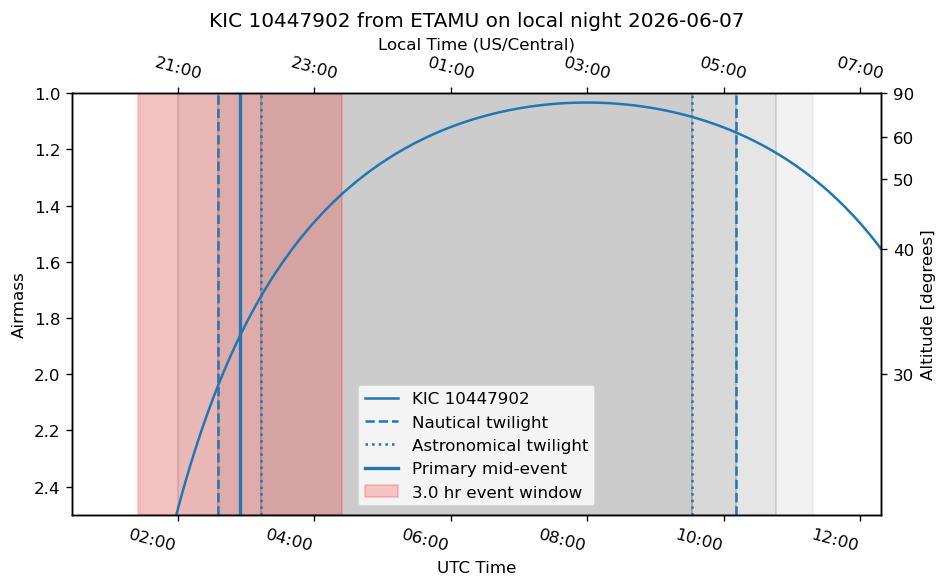

In [24]:
# Change these values after inspecting the event table.
obs_day = "2026-06-07"
site_name = "ETAMU"
target_name = "KIC 10447902"

fig, ax = plot_night_target_plan(master_table, obs_day, site_name, target_name, event_duration_hr=3)


### 6.3 Inspect the sky field with `ipyaladin`

The airmass plot tells you **when** the target is observable. The sky field tells you **what is around it**. This matters for differential photometry because you need comparison stars and a field that is not too crowded or contaminated.



In [29]:
def show_finder_chart(event_table, obs_day, site_name, target_name, fov_deg=10/60):
    """Open an interactive Aladin finder chart centered on the target coordinates."""
    try:
        import ipyaladin
    except ImportError:
        print("Install ipyaladin to use the interactive finder chart: pip install ipyaladin")
        return None
    row = get_event_row(event_table, obs_day, site_name, target_name)
    target_string = f"{row['RAJ2000']} {row['DEJ2000']}"
    viewer = ipyaladin.Aladin(target=target_string, fov=fov_deg, survey="P/DSS2/color", reticle_color="red", reticle_size=24, layout={"width": "700px", "height": "450px"})
    display(viewer)
    return viewer

viewer = show_finder_chart(master_table, obs_day, site_name, target_name)


```{admonition} Finder-chart checks
:class: tip

Before observing, inspect the target field. Look for nearby stars of similar brightness, obvious blends, saturation risks, bad crowding, and whether the target is near the edge of the detector for the planned pointing.
```

## 7. Use external planning tools

Python planning gives a reproducible record, but external web tools are still useful. Use them as **cross-checks** and **quick-look planning aids**, not as replacements for the planning notebook and observation log.

The best habit is to keep a short record of every external tool setting that affected the observing decision: site, date window, time zone, elevation limit, baseline requirement, magnitude/depth cut, Moon check, and weather source.

### 7.1 Use airmass.org for Moon-aware altitude checks

Use [airmass.org](https://airmass.org/) when you want a quick altitude diagram that also includes the Moon. Enter the target name or coordinates, choose the observing site, and set the date. Record the Moon illumination, Moon altitude, and Moon-target separation in the log.

This is especially useful when the target is technically observable but the Moon is bright or nearby.

### 7.2 Use ExoClock for exoplanet transit checks

Use [ExoClock](https://www.exoclock.space/) when the target is a **known transiting exoplanet**. ExoClock is designed for monitoring and improving exoplanet transit ephemerides, so it is especially useful when the goal is to obtain a clean transit light curve that could support a larger timing campaign.

ExoClock is not the main tool for eclipsing binaries. For EBs, the catalog search and `astroplan` workflow should remain the primary planning path.

A practical ExoClock workflow is:

1. Open [ExoClock](https://www.exoclock.space/) and check the planet's entry under the database or ephemeris tools.
2. Confirm the target name, coordinates, period, duration, predicted mid-transit time, and any timing uncertainty listed for the planet.
3. If using an ExoClock account, make sure the observatory profile has the correct telescope, camera, and site coordinates.
4. Compare the ExoClock prediction with the event time from the Python notebook.
5. If the predicted mid-transit times disagree, do not average them casually. Check the ephemeris source, time standard, and target name. If the uncertainty is large, widen the observing block.
6. Record the ExoClock check in the observation log, including the date you checked it.

```{admonition} Exoplanet timing rule
:class: warning

For exoplanet transits, always include enough out-of-transit baseline. A good default is at least one hour before ingress and one hour after egress when the target altitude and weather allow it. If the ephemeris uncertainty is large, start earlier and continue later.
```

Use ExoClock most often for these questions:

| Question | Why ExoClock helps |
|---|---|
| Is this exoplanet transit still worth observing? | Ephemerides can drift, especially when older timings are uncertain. |
| What mid-transit time should I expect? | ExoClock focuses on transit timing predictions and updates. |
| Could our observation contribute to a larger timing effort? | The project is built around coordinated follow-up of exoplanet transits. |
| What should I record for a possible submission? | ExoClock emphasizes observatory setup, timing, and complete light curves. |

### 7.3 Use the Swarthmore College Transit Finder

Use the [Swarthmore College Transit Finder](https://astro.swarthmore.edu/transits/) when you want a fast, web-based list of **observable exoplanet transits** for a date range and site. It is especially useful as an independent check on the Python event table.

For ETAMU, use manual site entry unless the site has been added to the observatory menu:

| Field | ETAMU value |
|---|---|
| Latitude | `33.246666` degrees |
| Longitude | `-95.899722` degrees, because west longitude is negative |
| Time zone | `U.S. - Central Time` |

For SARA sites, use the observatory menu when possible. The Transit Finder list includes common professional observatories such as Kitt Peak National Observatory, Cerro Tololo Inter-American Observatory, and Roque de los Muchachos. If a site is missing or ambiguous, enter the latitude, longitude, and time zone manually.

A practical Transit Finder workflow is:

1. Choose the target list. Use the **NASA Exoplanet Archive** list for confirmed exoplanets. Use the **TOI** list only when you intentionally want TESS Objects of Interest.
2. Enter the observing site. For ETAMU, use the manual latitude/longitude/time-zone fields.
3. Set the base date and search length. For this REU workflow, use the next 7--14 nights.
4. Set an elevation limit. A good starting value is 25--30 degrees at ingress and egress. Raise this if the target is faint or the weather is poor.
5. Require out-of-transit baseline. Start with at least 1 hour before ingress and 1 hour after egress.
6. Set useful target filters. Brightness and transit depth cuts can keep the output from being too long.
7. Choose the day/night definition. Astronomical twilight is strict; nautical twilight may be useful when you need a longer baseline and the target is bright.
8. View the HTML table for browsing, or export a CSV to compare the results with the Python table.
9. Open the linked airmass plots and finder charts for promising targets, but still make a complete nightly plan and log.

```{admonition} Time-zone check
:class: warning

Transit Finder can display results in UTC or local time depending on the selected option. Before copying any time into the observation log, label it as UTC or local time. Do not mix the two in the same table without labels.
```

Use Transit Finder most often for these questions:

| Question | Why Transit Finder helps |
|---|---|
| What exoplanet transits are observable from ETAMU this week? | It quickly filters events by site, date, elevation, and baseline. |
| Does the Python search miss an obvious exoplanet target? | It provides an independent catalog-based check. |
| Can I get a quick finder chart or airmass plot? | The output links to finding charts and airmass plots. |
| Can I export the result? | CSV output makes it easy to compare against the notebook table. |

### 7.4 How to combine Python, ExoClock, and Transit Finder

Use this priority order:

1. **Python notebook:** the main reproducible search and nightly planning record.
2. **ExoClock:** exoplanet ephemeris and timing cross-check for known planets.
3. **Transit Finder:** independent web-based search for observable exoplanet transits.
4. **airmass.org:** Moon-aware altitude check.
5. **Clear Sky Chart and local weather:** go/no-go decision.

For exoplanets, a good target should survive all checks: the Python table says it is observable, ExoClock or Transit Finder gives a consistent transit window, the airmass/Moon situation is acceptable, and the weather forecast is good enough to justify opening.

For eclipsing binaries, ExoClock and Transit Finder are usually not relevant. Use the EB catalog search, the nightly `astroplan` plot, the finder chart, and the weather checks.

```{admonition} Do not outsource the decision
:class: warning

A web tool can suggest a target, but it does not know the full observing plan. The observer is responsible for checking target altitude, event timing, baseline coverage, field crowding, Moon separation, weather, instrument setup, and whether the data will answer the science question.
```

### 7.5 Use Clear Sky Chart for ETAMU weather checks

For the ETAMU observatory, check both nearby Clear Sky Chart pages:

- [Greenville Clear Sky Chart](https://www.cleardarksky.com/c/GrnvllTXkey.html?1=)
- [Sulphur Springs Clear Sky Chart](https://www.cleardarksky.com/c/SSprgTXkey.html?1=)

Record cloud cover, transparency, seeing, humidity/dew risk, wind, and any local notes. Treat these as forecasts, not guarantees. If Greenville and Sulphur Springs disagree, say so in the log and make a conservative plan.

```{admonition} Weather decision rule
:class: warning

Do not rely on a single weather source. For student observing, the safest approach is to check Clear Sky Chart, a standard weather forecast, satellite/radar if relevant, and the sky conditions at the observatory before opening.
```

## 8. Structured observation log format

Use a structured observation log rather than a loose list of notes. The format below is based on the [research logging tutorial](https://saturnaxis.github.io/exoplanet-binary/Tutorials/research-log.html#logging-observations), with additional fields that are useful for time-series photometry.

Copy this template into a dated file such as `logs/2026-06-08_observation-log.md`.

```markdown
# Observation Log: YYYY-MM-DD Local Night

## 1. Planning summary

Date prepared:
- YYYY-MM-DD

Observer(s):
-

Observing site:
- Site:
- Telescope/instrument:
- Time zone:

Science goal:
-

Priority targets:
| Priority | Target | Event | Mid-event UTC | Planned block UTC | Filter | Exposure | Notes |
|---:|---|---|---|---|---|---:|---|
| 1 |  |  |  |  |  |  |  |
| 2 |  |  |  |  |  |  |  |
| Backup |  |  |  |  |  |  |  |

## 2. Target information

| Target | RA | Dec | Mag | Period | Catalog | Reason selected |
|---|---:|---:|---:|---:|---|---|
|  |  |  |  |  |  |  |

## 3. Night boundaries

| Event | UTC | Local time |
|---|---|---|
| Sunset |  |  |
| End nautical twilight |  |  |
| End astronomical twilight |  |  |
| Start astronomical twilight |  |  |
| Start nautical twilight |  |  |
| Sunrise |  |  |

## 4. Moon and weather

Moon:
- Illumination:
- Moon altitude during science block:
- Moon-target separation:
- Source checked: airmass.org / other

Weather forecast:
- Clear Sky Chart location(s): Greenville / Sulphur Springs / other
- Cloud cover:
- Transparency:
- Seeing:
- Wind:
- Humidity/dew risk:
- Go/no-go decision:

## 5. Calibration plan

Bias:
-

Darks:
-

Flats:
-

Filter(s):
-

## 6. Actual observing notes

| UTC time | Action | Target/filter/exposure | Conditions | Notes |
|---|---|---|---|---|
|  |  |  |  |  |

Focus:
- Initial focus:
- Focus changes:
- FWHM estimates:

Photometry setup notes:
- Aperture radius:
- Gap:
- Annulus:
- Comparison-star notes:

## 7. Data record

Raw data location:
-

File pattern(s):
-

Number of science frames:
-

Calibration files:
-

Known problems:
-

## 8. End-of-night summary

What was successfully observed?
-

What changed from the plan?
-

What should be checked in reduction?
-

Next steps:
-
```

## 9. Example: completed observing log

The example below shows how a completed observing log should look after a night at CTIO. The goal is for another student to be able to understand the plan, recover the observing sequence, find the data, and identify any issues that need to be checked during reduction.

```markdown
# Observation Log: 2026-03-30 Local Night

## 1. Planning summary

Date prepared:
- 2026-03-30

Observer(s):
- [fill in]

Observing site:
- Site: CTIO
- Telescope/instrument: SARA South / CCD imager
- Time zone: America/Santiago

Science goal:
- Observe two TESS eclipsing binaries. TIC 0220029715 completes a primary+secondary pair begun on 2026-03-06. TIC 0403757320 is a high-altitude earlier primary eclipse.

Priority targets:
| Priority | Target | Event | Mid-event UTC | Planned block UTC | Filter | Exposure | Notes |
|---:|---|---|---|---|---|---:|---|
| 1 | TIC 0220029715 | Secondary | 2026-03-31 05:36:34 | 2026-03-31 04:06--07:06 | Bessell V | 45 s used | Completes pair |
| 2 | TIC 0403757320 | Primary | 2026-03-31 03:16:18 | 2026-03-31 01:46--04:46 | Bessell V | 30 s used | Earlier block |
| Backup | TIC 0415528958 | Secondary | [fill in] | [fill in] | Bessell V | [fill in] | Good altitude backup |
| Backup | TIC 0306580215 | Secondary | [fill in] | [fill in] | Bessell V | [fill in] | Lower altitude backup |

## 2. Target information

| Target | RA | Dec | Mag | Period | Catalog | Reason selected |
|---|---:|---:|---:|---:|---|---|
| TIC 0220029715 | [fill in] | [fill in] | 12.43 | 3.1874984 d | TESS EB | Completes primary+secondary coverage |
| TIC 0403757320 | [fill in] | [fill in] | 11.19 | 1.0025046 d | TESS EB | High altitude and useful brightness |

## 3. Moon and weather

Weather notes:
- Clear skies at start.
- Humidity approximately 30% at start.
- Humidity dropped to approximately 20% later in the night.

Moon:
- [fill in from airmass.org or ephemeris check]

## 4. Calibration and setup

Filter:
- Bessell V

Flats:
- 23:00 UTC: 20 × 5 s
- 23:00 UTC: 10 × 10 s
- 23:00 UTC: 5 × 20 s
- 23:00 UTC: 5 × 30 s

Focus:
- 23:30 UTC: focus found at 130210, FWHM approximately 1.5 arcsec.
- Later focus changed to 129300, FWHM approximately 1.1 arcsec.

## 5. Actual observing notes

| UTC time | Action | Target/filter/exposure | Conditions | Notes |
|---|---|---|---|---|
| 23:00 | Took flats | Bessell V, 5--30 s | Clear | See calibration list above |
| 23:30 | Found focus | Focus 130210 | Clear, humidity ~30% | FWHM ~1.5 arcsec |
| 23:30 | Moved to target | TIC 0403757320 | Clear | Begin first science target |
| 23:30 | Started science images | TIC 0403757320, Bessell V, 30 s, set of 180 | Clear | Photometry aperture 12, gap 10, annulus 10 |
| 03:19 | Took darks and moved target | TIC 0220029715 next | Humidity falling | Verify exact order from FITS headers |
| 03:02 | Started/continued science images | TIC 0220029715, Bessell V, 45 s, set of 2400 | Humidity ~20% | Time appears out of order relative to 03:19 note; verify from FITS headers |
| 07:00 | Took darks/biases | Calibration frames | End of night |  |

## 6. Data record

Raw data location:
- [fill in]

File pattern(s):
- TIC 0403757320: [fill in]
- TIC 0220029715: [fill in]

Calibration files:
- Flats: Bessell V flats from 23:00 UTC.
- Darks: taken around 03:19 UTC and/or end of night.
- Biases: taken around 07:00 UTC.

Known problems:
- The log contains a possible time-order conflict: 03:02 UTC and 03:19 UTC entries should be checked against FITS timestamps.

## 7. End-of-night summary

What was successfully observed?
- TIC 0403757320 primary eclipse block.
- TIC 0220029715 secondary eclipse block.

What should be checked in reduction?
- Confirm exact start and end times from FITS headers.
- Check whether the 30 s and 45 s exposure times kept the targets below saturation.
- Inspect whether focus changes or humidity changes affected the light curves.
- Confirm comparison stars and aperture choices in AstroImageJ.

Next steps:
- Copy raw data into the project `data/raw/` folder.
- Save the final observation log in `logs/`.
- Begin image inspection and differential photometry.
```

```{admonition} Why structured logs are better
:class: tip

A short list of observing notes may tell you what happened, but a structured log makes the data reproducible. It separates the plan from the actual observing sequence, records the time system, preserves calibration details, and flags inconsistencies that must be checked against the FITS headers.
```

## 10. Putting everything together: a student workflow

Use this workflow for a normal REU observing cycle.

### Two weeks before observing

1. Set `START_DATE` and `END_DATE` for the next 7--14 nights.
2. Run the event-search notebook.
3. Save `observable_events_next_two_weeks.csv`.
4. Look for nights with good TESS EB events at ETAMU.
5. For exoplanet nights, cross-check promising targets with ExoClock and/or the Swarthmore College Transit Finder.
6. Identify possible primary+secondary pair opportunities for EBs, or full-transit plus baseline opportunities for exoplanets.
7. Save a short planning log.

### One or two days before observing

1. Select 1--2 science targets and at least one backup.
2. Run the nightly planning notebook for the chosen site and date.
3. Save the airmass plot.
4. Open the finder chart and inspect the field.
5. For exoplanets, verify the event window against ExoClock or Transit Finder and record which source was checked.
6. Check the Moon with airmass.org.
7. Check weather using Clear Sky Chart and local forecasts.
8. Create the observation log file before the night starts.

### During observing

1. Record actual times in UTC.
2. Record focus values and FWHM estimates.
3. Record exposure times, filter, number of frames, and any changes.
4. Record weather changes, clouds, humidity, wind, and dew risk.
5. Record problems immediately. Do not wait until the next day.

### Morning after observing

1. Confirm file locations and file patterns.
2. Check FITS headers for actual start/end times.
3. Fill in missing log fields.
4. Note which frames may be bad.
5. Start the reduction notebook or AstroImageJ workflow.
6. Write the next step at the bottom of the log.

## 11. Common mistakes

| Mistake | Why it causes problems | Fix |
|---|---|---|
| Planning by UTC date only | Local night and UTC date can differ | Always record both local date and UTC time |
| Trusting one plot | Airmass, Moon, field crowding, and weather are separate checks | Use Python, airmass.org, finder chart, and weather tools |
| Using only target name resolution | TIC names may fail or resolve inconsistently | Use RA/Dec from the event table when possible |
| Not saving the event table | You cannot reconstruct why a target was chosen | Save the CSV and log the filename |
| Not recording exposure changes | Reduction becomes confusing | Record every exposure-time or filter change |
| Not recording failed attempts | The same problem gets rediscovered later | Log errors, false starts, and bad frames |
| Forgetting Moon information | Bright Moon can ruin otherwise good photometry | Record Moon illumination, altitude, and separation |
| Copying web-tool times without labels | UTC and local times can be confused | Label every time and record the tool setting |
| Trusting web-tool output without saving settings | You cannot reproduce the decision later | Record site, date range, elevation cuts, baseline, and filters |

## 12. Final observing checklist

Before starting the night, every student should be able to answer these questions:

- What target is highest priority?
- What is the event type?
- What is the mid-event time in UTC?
- What local time does that correspond to?
- What is the planned observing block?
- What filter and exposure time will be used first?
- What is the backup target?
- Is the Moon a problem?
- For exoplanets, did ExoClock or Transit Finder agree with the planned event window?
- Is the weather good enough to observe?
- Where will the raw data be saved?
- Where is the observation log?

If you cannot answer one of these questions, the plan is not ready yet.

## 13. Useful links

- [Research Logging: Logging Observations](https://saturnaxis.github.io/exoplanet-binary/Tutorials/research-log.html#logging-observations)
- [Celestial Sphere and Sky Coordinates](https://saturnaxis.github.io/exoplanet-binary/Tutorials/celestial-sphere.html#)
- [astroplan: Observing Transiting Exoplanets and Eclipsing Binaries](https://astroplan.readthedocs.io/en/latest/tutorials/periodic.html)
- [astroplan: Plotting with Astroplan](https://astroplan.readthedocs.io/en/stable/tutorials/plots.html)
- [airmass.org](https://airmass.org/)
- [ExoClock](https://www.exoclock.space/)
- [Swarthmore College Transit Finder](https://astro.swarthmore.edu/transits/)
- [Greenville Clear Sky Chart](https://www.cleardarksky.com/c/GrnvllTXkey.html?1=)
- [Sulphur Springs Clear Sky Chart](https://www.cleardarksky.com/c/SSprgTXkey.html?1=)
